In [54]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.tree import DecisionTreeRegressor, export_text

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import root_mean_squared_error

import matplotlib.pyplot as plt

### Dataset

In this homework, we will use the California Housing Prices from [Kaggle](https://www.kaggle.com/datasets/camnugent/california-housing-prices).

Here's a wget-able [link](https://raw.githubusercontent.com/alexeygrigorev/datasets/master/housing.csv):

```bash
wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/housing.csv
```

The goal of this homework is to create a regression model for predicting housing prices (column `'median_house_value'`).

In [2]:
!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/housing.csv

--2024-10-06 07:28:21--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/housing.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8003::154, 2606:50c0:8000::154, 2606:50c0:8001::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8003::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1423529 (1.4M) [text/plain]
Saving to: ‘housing.csv’

housing.csv         100%[===================>]   1.36M  --.-KB/s    in 0.1s    

2024-10-06 07:28:21 (10.5 MB/s) - ‘housing.csv’ saved [1423529/1423529]



In [3]:
df = pd.read_csv('housing.csv')

In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Preparing the dataset 

For this homework, we only want to use a subset of data. This is the same subset we used in homework #2.
But in contrast to homework #2, we are going to use all columns of the dataset.

First, keep only the records where `ocean_proximity` is either `'<1H OCEAN'` or `'INLAND'`

Preparation:

* Fill missing values with zeros.
* Apply the log transform to `median_house_value`.
* Do train/validation/test split with 60%/20%/20% distribution. 
* Use the `train_test_split` function and set the `random_state` parameter to 1.
* Use `DictVectorizer(sparse=True)` to turn the dataframes into matrices.

In [5]:
df = df.loc[df['ocean_proximity'].isin(['<1H OCEAN', 'INLAND'])]

In [6]:
df.ocean_proximity.unique()

array(['<1H OCEAN', 'INLAND'], dtype=object)

In [7]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        157
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [8]:
df = df.fillna(0)

In [9]:
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [10]:
df['median_house_value'] = np.log1p(df['median_house_value'])

In [11]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
701,-121.97,37.64,32.0,1283.0,194.0,485.0,171.0,6.0574,12.973866,<1H OCEAN
830,-121.99,37.61,9.0,3666.0,711.0,2341.0,703.0,4.6458,12.287657,<1H OCEAN
859,-121.97,37.57,21.0,4342.0,783.0,2172.0,789.0,4.6146,12.419574,<1H OCEAN
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,12.554971,<1H OCEAN
861,-121.98,37.58,20.0,4126.0,1031.0,2079.0,975.0,3.6832,12.287196,<1H OCEAN


In [25]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

y_full_train = df_full_train.median_house_value.values
y_train = df_train.median_house_value.values
y_val = df_val.median_house_value.values
y_test = df_test.median_house_value.values

del df_full_train['median_house_value']
del df_train['median_house_value']
del df_test['median_house_value']

In [26]:
assert len(df_train) == len(y_train)
assert len(df_val) == len(df_test) == len(y_val) == len(y_test)

In [28]:
dv = DictVectorizer(sparse=True)

train_dicts = df_train.to_dict(orient='records')
val_dicts = df_val.to_dict(orient='records')
test_dicts = df_test.to_dict(orient='records')

X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)
X_test = dv.transform(test_dicts)

## Question 1

Let's train a decision tree regressor to predict the `median_house_value` variable. 

* Train a model with `max_depth=1`.


Which feature is used for splitting the data?

* `ocean_proximity`
* `total_rooms`
* `latitude`
* `population`

In [37]:
dt = DecisionTreeRegressor(max_depth=1)

dt.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=1)

In [38]:
print(export_text(dt, feature_names=list(dv.get_feature_names_out())))

|--- ocean_proximity=<1H OCEAN <= 0.50
|   |--- value: [11.61]
|--- ocean_proximity=<1H OCEAN >  0.50
|   |--- value: [12.30]



answer: ocean_proximity

## Question 2

Train a random forest model with these parameters:

* `n_estimators=10`
* `random_state=1`
* `n_jobs=-1` (optional - to make training faster)


What's the RMSE of this model on validation?

* 0.045
* 0.245
* 0.545
* 0.845

In [41]:
rf = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)
rmse = round(root_mean_squared_error(y_val, y_pred), 3)
rmse

0.245

answer: 0.245

## Question 3

Now let's experiment with the `n_estimators` parameter

* Try different values of this parameter from 10 to 200 with step 10.
* Set `random_state` to `1`.
* Evaluate the model on the validation dataset.


After which value of `n_estimators` does RMSE stop improving?
Consider 3 decimal places for calculating the answer.

- 10
- 25
- 50
- 160

In [49]:
from tqdm import tqdm

In [52]:
scores = []

rf = RandomForestRegressor(
    n_estimators=1,
    random_state=1,
    n_jobs=-1,
    warm_start=True,
)

for n in tqdm(range(10, 201, 10)):
    rf.n_estimators = n
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)
    scores.append([n, rmse])
    # print(f"n_estimators: {n} ---> rmse: {rmse}")
df_scores = pd.DataFrame(scores, columns=['n_esitmators', 'rmse'])

100%|███████████████████████████████████████████| 20/20 [00:08<00:00,  2.34it/s]


In [53]:
df_scores

,n_esitmators,rmse
0,10,0.244946
1,20,0.238916
2,30,0.236837
3,40,0.234998
4,50,0.234606
5,60,0.234194
6,70,0.234193
7,80,0.234387
8,90,0.234290
9,100,0.234159


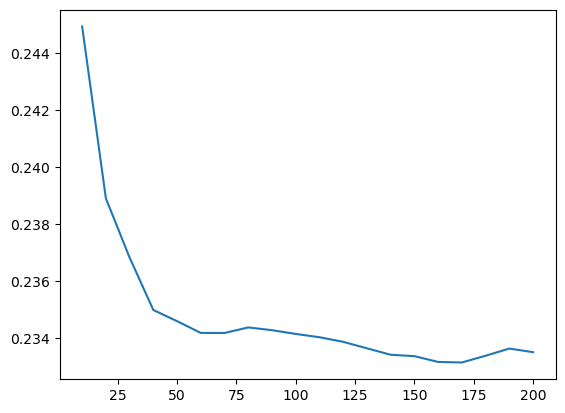

In [56]:
plt.plot(df_scores['n_esitmators'], df_scores['rmse'])

answer: approximately 160

## Question 4

Let's select the best `max_depth`:

* Try different values of `max_depth`: `[10, 15, 20, 25]`
* For each of these values,
  * try different values of `n_estimators` from 10 till 200 (with step 10)
  * calculate the mean RMSE 
* Fix the random seed: `random_state=1`


What's the best `max_depth`, using the mean RMSE?

* 10
* 15
* 20
* 25

In [93]:
#scores = []
for md in [10, 15, 20, 25]:
    scores = []
    

    #print(f"max_depth: {md}")
    rf = RandomForestRegressor(
        n_estimators=1,
        max_depth=md,
        random_state=1,
        n_jobs=-1,
        warm_start=True,
    )
    
    for n in tqdm(range(10, 201, 10)):
        rf.n_estimators = n
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_val)
        rmse = root_mean_squared_error(y_val, y_pred)
        # scores.append([md, n, rmse])
        scores.append(rmse)
        #print(f"    n_estimators: {n} ---> rmse: {rmse}")
    print(f"max_depth: {md} ----> mean_rmse: {np.mean(scores):0.5f}")
#df_scores = pd.DataFrame(scores, columns=["max_depth", 'n_esitmators', 'rmse'])

100%|███████████████████████████████████████████| 20/20 [00:03<00:00,  6.20it/s]


max_depth: 10 ----> mean_rmse: 0.24558


100%|███████████████████████████████████████████| 20/20 [00:05<00:00,  3.44it/s]


max_depth: 15 ----> mean_rmse: 0.23590


100%|███████████████████████████████████████████| 20/20 [00:08<00:00,  2.50it/s]


max_depth: 20 ----> mean_rmse: 0.23474


100%|███████████████████████████████████████████| 20/20 [00:08<00:00,  2.39it/s]

max_depth: 25 ----> mean_rmse: 0.23514


In [86]:
scores

[[10, 10, 0.25091511747078393],
 [10, 20, 0.24758707220466802],
 [10, 30, 0.24637640327960636],
 [10, 40, 0.2451600726298701],
 [10, 50, 0.245555529712163],
 [10, 60, 0.24537643880890128],
 [10, 70, 0.2454503865468275],
 [10, 80, 0.2456745499553153],
 [10, 90, 0.24556402313731107],
 [10, 100, 0.24555157286899945],
 [10, 110, 0.2454134840985485],
 [10, 120, 0.24518917273017596],
 [10, 130, 0.24494263249598272],
 [10, 140, 0.24471808951926974],
 [10, 150, 0.24469142838960703],
 [10, 160, 0.2445941821401139],
 [10, 170, 0.24455286284150243],
 [10, 180, 0.24466081924623126],
 [10, 190, 0.24483632876746164],
 [10, 200, 0.2448355398539169],
 [15, 10, 0.2455720651355785],
 [15, 20, 0.23950538470145052],
 [15, 30, 0.23765688998405998],
 [15, 40, 0.23617552458765093],
 [15, 50, 0.23598341113996138],
 [15, 60, 0.23569817324646328],
 [15, 70, 0.2357339791482076],
 [15, 80, 0.23576182235903645],
 [15, 90, 0.23542104488456075],
 [15, 100, 0.2352700594958291],
 [15, 110, 0.2350878977107164],
 [15, 1

In [85]:
df_scores

,max_depth,n_esitmators,rmse
0,10,10,0.250915
1,10,20,0.247587
2,10,30,0.246376
3,10,40,0.245160
4,10,50,0.245556
...,...,...,...
75,25,160,0.233513
76,25,170,0.233510
77,25,180,0.233726
78,25,190,0.233954


In [75]:
for m in df_scores['max_depth'].unique():
    mean_rmse = df_scores.loc[df_scores['max_depth'] == m, 'rmse'].mean()
    print(f"max_depth: {m} ----> mean_rmse: {mean_rmse}")

max_depth: 10 ----> mean_rmse: 0.24558228533486282
max_depth: 15 ----> mean_rmse: 0.23590062713833032
max_depth: 20 ----> mean_rmse: 0.23473527542877365
max_depth: 25 ----> mean_rmse: 0.23513883127959812


In [76]:
for m in df_scores['max_depth'].unique():
    mean_rmse = df_scores.loc[df_scores['max_depth'] == m, 'rmse'].mean()
    print(f"max_depth: {m} ----> mean_rmse: {mean_rmse}")

max_depth: 10 ----> mean_rmse: 0.24558228533486282
max_depth: 15 ----> mean_rmse: 0.23590062713833032
max_depth: 20 ----> mean_rmse: 0.23473527542877365
max_depth: 25 ----> mean_rmse: 0.23513883127959812


In [67]:
df_scores

,n_esitmators,max_depth,rmse
0,10,10,0.250915
1,10,20,0.247587
2,10,30,0.246376
3,10,40,0.245160
4,10,50,0.245556
...,...,...,...
75,25,160,0.233513
76,25,170,0.233510
77,25,180,0.233726
78,25,190,0.233954


answer: 20

# Question 5

We can extract feature importance information from tree-based models. 

At each step of the decision tree learning algorithm, it finds the best split. 
When doing it, we can calculate "gain" - the reduction in impurity before and after the split. 
This gain is quite useful in understanding what are the important features for tree-based models.

In Scikit-Learn, tree-based models contain this information in the
[`feature_importances_`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html#sklearn.ensemble.RandomForestRegressor.feature_importances_)
field. 

For this homework question, we'll find the most important feature:

* Train the model with these parameters:
  * `n_estimators=10`,
  * `max_depth=20`,
  * `random_state=1`,
  * `n_jobs=-1` (optional)
* Get the feature importance information from this model


What's the most important feature (among these 4)? 

* `total_rooms`
* `median_income`
* `total_bedrooms`
* `longitude`

In [94]:
rf = RandomForestRegressor(n_estimators=10,
                          max_depth=20,
                          random_state=1,
                          n_jobs=-1)

rf.fit(X_train, y_train)


RandomForestRegressor(max_depth=20, n_estimators=10, n_jobs=-1, random_state=1)

In [107]:
impts = []
feature_importances = rf.feature_importances_
for i, feature in enumerate(dv.feature_names_):
    #print(f"feature: {feature} ---> feature_importance: {feature_importances[i]:.3f}")
    impts.append((feature, feature_importances[i]))

df_fi = pd.DataFrame(impts, columns=['feature', 'feature_importance'])

In [108]:
df_fi.sort_values(['feature_importance'], ascending=False)

,feature,feature_importance
4,median_income,0.335563
5,ocean_proximity=<1H OCEAN,0.292473
2,latitude,0.101855
3,longitude,0.086367
6,ocean_proximity=INLAND,0.073806
1,housing_median_age,0.030003
7,population,0.027353
9,total_rooms,0.021723
0,households,0.015527
8,total_bedrooms,0.015328


In [103]:
df_fi.sort_values(['feature_importance'], ascending=False)

,feature,feature_importance
4,median_income,0.335563
5,ocean_proximity=<1H OCEAN,0.292473
2,latitude,0.101855
3,longitude,0.086367
6,ocean_proximity=INLAND,0.073806
1,housing_median_age,0.030003
7,population,0.027353
9,total_rooms,0.021723
0,households,0.015527
8,total_bedrooms,0.015328


answer: median_income

## Question 6

Now let's train an XGBoost model! For this question, we'll tune the `eta` parameter:

* Install XGBoost
* Create DMatrix for train and validation
* Create a watchlist
* Train a model with these parameters for 100 rounds:

```
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}
```

Now change `eta` from `0.3` to `0.1`.

Which eta leads to the best RMSE score on the validation dataset?

* 0.3
* 0.1
* Both give equal value

In [110]:
import xgboost as xgb
from xgboost import DMatrix

In [111]:
features = dv.feature_names_
features = [f.replace('<', 'less ') for f in features]
features

['households',
 'housing_median_age',
 'latitude',
 'longitude',
 'median_income',
 'ocean_proximity=less 1H OCEAN',
 'ocean_proximity=INLAND',
 'population',
 'total_bedrooms',
 'total_rooms']

In [113]:
dtrain = DMatrix(data=X_train, label=y_train, feature_names=features)
dval = DMatrix(data=X_val, label=y_val, feature_names=features)

In [114]:
watchlist = [(dtrain, 'train'), (dval, 'val')]
scores = {}

In [ ]:
model.

In [116]:
xgb_params = {
    'eta': 0.1, 
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'reg:squarederror',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=100,
                  verbose_eval=5, evals=watchlist)

[0]	train-rmse:0.52449	val-rmse:0.52045
[5]	train-rmse:0.37822	val-rmse:0.38151
[10]	train-rmse:0.30326	val-rmse:0.31427
[15]	train-rmse:0.26538	val-rmse:0.28380
[20]	train-rmse:0.24512	val-rmse:0.26882
[25]	train-rmse:0.23026	val-rmse:0.25997
[30]	train-rmse:0.21887	val-rmse:0.25266
[35]	train-rmse:0.21020	val-rmse:0.24826
[40]	train-rmse:0.20392	val-rmse:0.24539
[45]	train-rmse:0.19814	val-rmse:0.24293
[50]	train-rmse:0.19215	val-rmse:0.24020
[55]	train-rmse:0.18809	val-rmse:0.23878
[60]	train-rmse:0.18457	val-rmse:0.23791
[65]	train-rmse:0.18063	val-rmse:0.23698
[70]	train-rmse:0.17741	val-rmse:0.23622
[75]	train-rmse:0.17468	val-rmse:0.23510
[80]	train-rmse:0.17242	val-rmse:0.23453
[85]	train-rmse:0.17014	val-rmse:0.23404
[90]	train-rmse:0.16797	val-rmse:0.23332
[95]	train-rmse:0.16562	val-rmse:0.23276
[99]	train-rmse:0.16323	val-rmse:0.23209


In [123]:
def parse_xgb_output(output):
    results = []

    for line in output.strip().split('\n'):
    #for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        results.append((it, train, val))
    
    columns = ['num_iter', 'train_auc', 'val_auc']
    df_results = pd.DataFrame(results, columns=columns)
    return df_results

[0]	train-rmse:0.44350	val-rmse:0.44250
[10]	train-rmse:0.21444	val-rmse:0.25179
[20]	train-rmse:0.18524	val-rmse:0.23978
[30]	train-rmse:0.16888	val-rmse:0.23570
[40]	train-rmse:0.15542	val-rmse:0.23318
[50]	train-rmse:0.14536	val-rmse:0.23225
[60]	train-rmse:0.13719	val-rmse:0.23139
[70]	train-rmse:0.12943	val-rmse:0.23068
[80]	train-rmse:0.12192	val-rmse:0.22886
[90]	train-rmse:0.11496	val-rmse:0.22861
[99]	train-rmse:0.10989	val-rmse:0.22862


<Axes: xlabel='num_iter'>

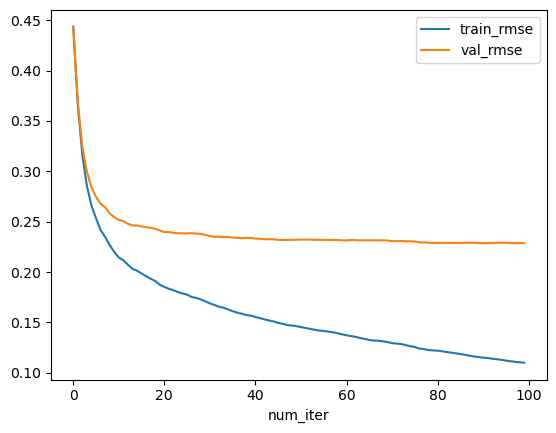

In [153]:
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'reg:squarederror',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1,
}

evals_result = {}  # To store training results

model = xgb.train(xgb_params, dtrain, num_boost_round=100,
                  verbose_eval=10, evals=watchlist, evals_result=evals_result)

# Convert the results to a DataFrame
df_results = pd.DataFrame({
    'num_iter': range(len(evals_result['train']['rmse'])),
    'train_rmse': evals_result['train']['rmse'],
    'val_rmse': evals_result['val']['rmse']
})

# Plotting the results
df_results.plot(x='num_iter', y=['train_rmse', 'val_rmse'])


[0]	train-rmse:0.52449	val-rmse:0.52045
[10]	train-rmse:0.30326	val-rmse:0.31427
[20]	train-rmse:0.24512	val-rmse:0.26882
[30]	train-rmse:0.21887	val-rmse:0.25266
[40]	train-rmse:0.20392	val-rmse:0.24539
[50]	train-rmse:0.19215	val-rmse:0.24020
[60]	train-rmse:0.18457	val-rmse:0.23791
[70]	train-rmse:0.17741	val-rmse:0.23622
[80]	train-rmse:0.17242	val-rmse:0.23453
[90]	train-rmse:0.16797	val-rmse:0.23332
[99]	train-rmse:0.16323	val-rmse:0.23209


<Axes: xlabel='num_iter'>

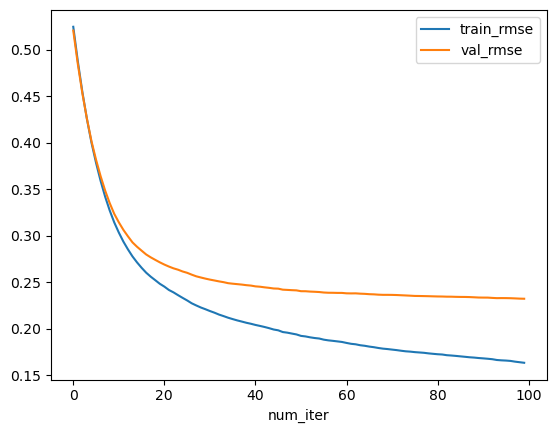

In [154]:
xgb_params = {
    'eta': 0.1, 
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'reg:squarederror',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1,
}

evals_result = {}  # To store training results

model = xgb.train(xgb_params, dtrain, num_boost_round=100,
                  verbose_eval=10, evals=watchlist, evals_result=evals_result)

# Convert the results to a DataFrame
df_results_1 = pd.DataFrame({
    'num_iter': range(len(evals_result['train']['rmse'])),
    'train_rmse': evals_result['train']['rmse'],
    'val_rmse': evals_result['val']['rmse']
})

# Plotting the results
df_results_1.plot(x='num_iter', y=['train_rmse', 'val_rmse'])

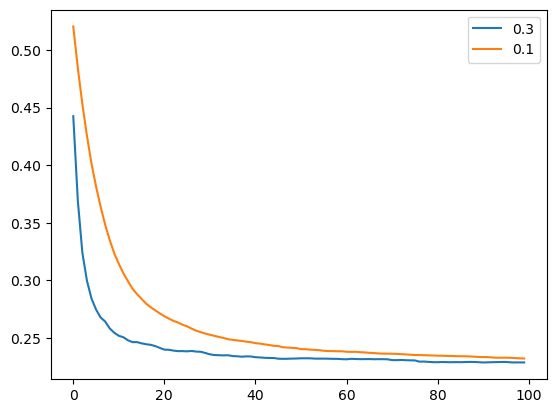

In [157]:
plt.plot(df_results['num_iter'], df_results['val_rmse'],
        label='0.3')
plt.plot(df_results['num_iter'], df_results_1['val_rmse'],
        label='0.1')
plt.legend()
plt.show()

answer: 0.3 gives the better result